---
# Wine Quality Classification
---

## Table of Contents

1. [**Initialization**](#1)
2. [**Project Approach**](#2)
3. [**Exploratory Data Analysis**](#3)
4. [**Advanced Data Preparation**](#4)
5. [**Robust Feature Selection**](#5)
6. [**Model Stability Analysis**](#6)
7. [**Adaptive Pseudo-Labeling**](#7)
8. [**Deep Learning Training**](#8)
9. [**Final Model Diagnostics**](#9)
10. [**Robust Inference & Submission**](#10)

---

# Introduction <a name="1"></a>

---

**Wine Quality Classification** adalah tugas prediktif deep learning: meningkatkan performa klasifikasi dataset kualitas wine melalui enological feature engineering dan Residual Deep Neural Network (DNN). Performa dievaluasi menggunakan **skor F1-Macro** dan **Quadratic Weighted Kappa**, dengan standar ketat untuk menjaga reliabilitas ordinal pada label kualitas 3-8. Notebook submission ini mengintegrasikan strategi penanganan ketidakseimbangan kelas ekstrem menggunakan Soft Labeling (distilasi pengetahuan dari model ExtraTrees) dan SMOTETomek. Pipeline pemodelan mencakup optimasi hyperparameter Bayesian via Optuna, penggunaan Focal Loss untuk prioritas kelas minoritas, serta strategi Robust Inference melalui Test-Time Augmentation (TTA) dan Hybrid Prediction Logic untuk menjamin konsistensi hasil akhir.

---

## Approach

Model ini dibangun di atas arsitektu**r Omni-Signal Residual Deep & Cross Network (DCN)** sebagai mesin inferensi utama. Kami menerapkan strategi **Enological Feature Engineering** yang dikombinasikan dengan **Latent Clustering** untuk menangkap karakteristik kimiawi wine yang kompleks. Untuk mengatasi ambiguitas pada label ordinal, kami menggunakan teknik **Soft Labeling** melalui prediktor ExtraTrees sebagai pengajar (teacher). Pelatihan model dioptimalkan menggunakan **Precision Ordinal Loss** (berbasis Focal Loss & Huber Penalty) dan Optuna untuk pencarian hyperparameter secara otomatis.
```
Input: Wine Quality Raw Data 
    |
    +-- Enological Engineering (Rasio Sulfur, Asam, & Interaksi Alk-Vol)
    |        |
    |        +-- Latent Clustering (KMeans k=4) -> Informasi Tipe Wine
    |        |        |
    |        |        v
    |        +-- Preprocessing (Yeo-Johnson PowerTransform & Scaling)
    |                 |
    |                 v
    +-- Soft Labeling (ExtraTrees OOF Distillation) -> Penanganan Ambiguitas
             |
             v
    Augmentasi Data (SMOTETomek & Adaptive Pseudo-Labeling)
             |
             v
    Omni-Signal Residual DCN (Cross Path, GLU, & Precision Ordinal Loss)
             |        |
             |        +-- Hyperparameter Tuning (Optuna Optimization)
             |
             v
    Ordinal Output Parsing (Label 3 - 8) -> Evaluasi Akhir

---

# Initialization <a name="2"></a>

---

Fase inisialisasi membangun landasan eksekusi dengan mengatur instalasi paket diagnostik, suite optimasi, serta konfigurasi global. Tahap ini memastikan integrasi dependensi eksternal yang mulus untuk mendukung pipeline pemrosesan data yang kompleks.

---
## Environment

In [1]:
import os, platform, sys
print('Python :', sys.version)
print('OS     :', platform.system(), platform.release())
print('CWD    :', os.getcwd())

Python : 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
OS     : Linux 6.6.122+
CWD    : /kaggle/working


---
## Install 

In [2]:
!pip install -U imbalanced-learn optuna -q

---
## Libraries & Patching

In [3]:
import os
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import optuna

from scipy.stats import skew
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.feature_selection import mutual_info_classif, RFECV
from sklearn.ensemble import ExtraTreesRegressor, ExtraTreesClassifier, VotingClassifier, RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict, RepeatedStratifiedKFold, cross_validate
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                             f1_score, cohen_kappa_score, mean_absolute_error)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from tensorflow.keras import constraints
from tensorflow.keras import models, constraints, callbacks
import optuna

# Pustaka Deep Learning
import tensorflow as tf
from tensorflow.keras import layers, callbacks, regularizers
from tensorflow.keras.models import Model # Import Model secara spesifik
from tensorflow.keras.utils import to_categorical

warnings.filterwarnings('ignore')

2026-05-07 13:15:01.975917: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778159702.444957      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778159702.573611      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778159703.727969      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778159703.728103      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778159703.728108      16 computation_placer.cc:177] computation placer alr

---
## Settings

In [4]:
# Konfigurasi Peringatan dan Tema Visualisasi
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Setup Path Dataset Dinamis (Kaggle Robust)
train_path = '/kaggle/input/datasets/dimaspashaakrilian/wine-quality/data_training.csv'
test_path = '/kaggle/input/datasets/dimaspashaakrilian/wine-quality/data_testing.csv'

# Verifikasi keberadaan jalur data
if not os.path.exists(train_path):
    for root, dirs, files in os.walk('/kaggle/input'):
        for file in files:
            if 'data_training' in file: train_path = os.path.join(root, file)
            if 'data_testing' in file: test_path = os.path.join(root, file)

# Memuat Dataset utama
df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

---
# Exploratory Data Analysis
---

---
## Enological Feature Engineering

Pada tahap ini, dilakukan pembuatan fitur baru yang didasarkan pada logika kimiawi wine (Enologi). Hal ini mencakup manajemen sulfur untuk kestabilan, profil total keasaman, serta interaksi alkohol yang menentukan tekstur (body) dari wine. Selain itu, ditambahkan fitur polinomial untuk membantu model menangkap pola non-linear.

In [5]:
# Pembuatan fitur berdasarkan logika kimiawi wine (Enologi)
for df in [df_train, df_test]:
    # 1. Sulfur Management (Sangat krusial untuk kestabilan wine)
    df['bound_so2'] = df['total sulfur dioxide'] - df['free sulfur dioxide']
    df['so2_ratio'] = df['free sulfur dioxide'] / (df['total sulfur dioxide'] + 1e-5)
    
    # 2. Acidity Profile (Total keasaman yang dirasakan lidah)
    df['total_acid'] = df['fixed acidity'] + df['volatile acidity']
    df['acid_ratio'] = df['citric acid'] / (df['total_acid'] + 1e-5)
    
    # 3. Alcohol & Mouthfeel (Interaksi yang menentukan 'body' wine)
    df['alc_vol_inter'] = df['alcohol'] * df['volatile acidity']
    df['alc_sulph_inter'] = df['alcohol'] * df['sulphates']
    
    # 4. Polynomial Features (Untuk menangkap pola non-linear DNN)
    df['alcohol_sq'] = df['alcohol'] ** 2
    df['volatile_sq'] = df['volatile acidity'] ** 2
    df['sulphates_sq'] = df['sulphates'] ** 2

---
## Latent Clustering

Langkah ini menggunakan algoritma K-Means untuk menemukan tipe wine tersembunyi berdasarkan karakteristik fisikokimia. Dengan mengelompokkan data menjadi 4 klaster, model diharapkan dapat mengenali pola laten yang membedakan kualitas wine secara lebih efektif.

In [6]:
# Menemukan tipe wine tersembunyi menggunakan KMeans
features_for_cluster = ['alcohol', 'volatile acidity', 'total sulfur dioxide', 'pH']
scaler = StandardScaler()
X_clust = scaler.fit_transform(df_train[features_for_cluster])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_train['wine_cluster'] = kmeans.fit_predict(X_clust)
df_test['wine_cluster'] = kmeans.predict(scaler.transform(df_test[features_for_cluster]))

---
## Diagnostik Fitur: Sinyal (MI) vs Redundansi (VIF)

Untuk memastikan fitur yang digunakan memiliki dampak nyata dan tidak menyebabkan multikolinearitas, dilakukan perhitungan Mutual Information (MI) Score untuk mengukur kekuatan sinyal terhadap target, serta Variance Inflation Factor (VIF) untuk mendeteksi redundansi antar fitur.

In [7]:
# Fungsi untuk menghitung VIF dan MI Score
def diagnostic_vif_mi(df):
    X = df.drop(columns=['Id', 'quality']).select_dtypes(include=[np.number])
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
    
    # Hitung MI Score secara bersamaan
    mi_scores = mutual_info_classif(X, df['quality'], random_state=42)
    vif_data["MI_Score"] = mi_scores
    return vif_data.sort_values(by="MI_Score", ascending=False)

print("\n--- Diagnostik Fitur: Sinyal (MI) vs Redundansi (VIF) ---")
analysis_df = diagnostic_vif_mi(df_train)
print(analysis_df)


--- Diagnostik Fitur: Sinyal (MI) vs Redundansi (VIF) ---
                 Feature           VIF  MI_Score
16       alc_sulph_inter  2.515057e+03  0.180555
10               alcohol  3.710964e+04  0.175690
17            alcohol_sq  8.587395e+03  0.164148
20          wine_cluster  5.515115e+00  0.155169
15         alc_vol_inter  1.370877e+03  0.129421
14            acid_ratio  1.489069e+02  0.124363
19          sulphates_sq  6.740632e+01  0.115541
9              sulphates  3.192002e+03  0.114948
6   total sulfur dioxide           inf  0.112094
1       volatile acidity           inf  0.100583
12             so2_ratio  3.230976e+01  0.097742
18           volatile_sq  5.460572e+01  0.096196
2            citric acid  1.888321e+02  0.094340
11             bound_so2           inf  0.074230
7                density  1.498882e+04  0.063684
13            total_acid           inf  0.063413
5    free sulfur dioxide           inf  0.044902
4              chlorides  7.755449e+00  0.043953
8         

---
## Visualisasi Pembeda Kelas

Visualisasi ini difokuskan pada fitur-fitur baru hasil interaksi untuk melihat kemampuannya dalam membedakan kelas kualitas wine. Boxplot digunakan untuk melihat distribusi interaksi alkohol dan sulfat, sementara scatter plot digunakan untuk melihat batas keputusan (decision boundary) antara alkohol dan keasaman volatil.

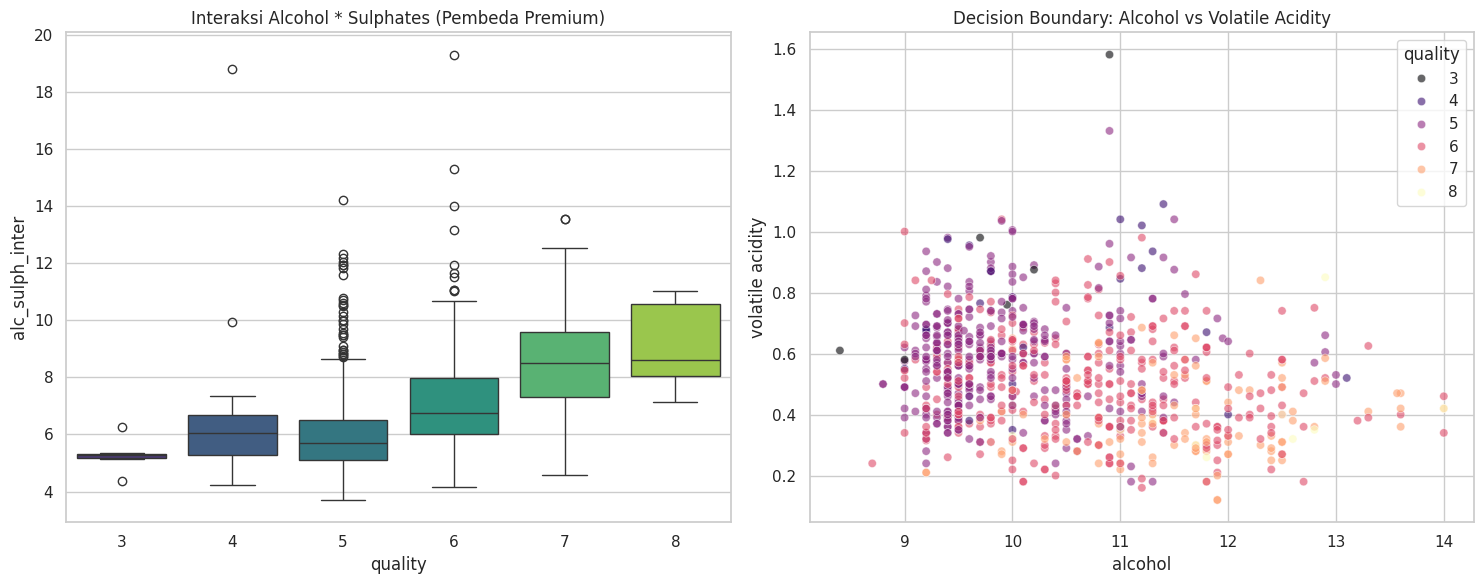


Total Fitur Sekarang: 21 Fitur


In [8]:
# Visualisasi untuk melihat distribusi sinyal baru terhadap kualitas
plt.figure(figsize=(15, 6))

# Boxplot Interaksi Alcohol * Sulphates
plt.subplot(1, 2, 1)
sns.boxplot(x='quality', y='alc_sulph_inter', data=df_train, palette='viridis')
plt.title('Interaksi Alcohol * Sulphates (Pembeda Premium)')

# Scatter Plot Decision Boundary
plt.subplot(1, 2, 2)
sns.scatterplot(x='alcohol', y='volatile acidity', hue='quality', data=df_train, palette='magma', alpha=0.6)
plt.title('Decision Boundary: Alcohol vs Volatile Acidity')

plt.tight_layout()
plt.show()

print(f"\nTotal Fitur Sekarang: {len(df_train.columns) - 2} Fitur")

---
# Data Preparation
---

---
## Advanced Feature Transformation

Pada fase ini, dilakukan transformasi murni pada data latih dan uji. Log-transformasi diterapkan untuk menekan efek variabel yang sangat miring (skewed), sementara fitur rasio baru disuntikkan untuk memperkuat sinyal antar variabel kimia. Fitur dengan redundansi tinggi (VIF ekstrim) dieliminasi untuk menjaga efisiensi komputasi.

In [9]:
# 3.1 Master Feature Engineering (High-Signal Injection)
def transform_features(df):
    df_new = df.copy()
    
    # 1. Log-Transformation untuk Sulfur & Sugar (Menangani Skewness)
    df_new['total_so2_log'] = np.log1p(df_new['total sulfur dioxide'])
    df_new['sugar_log'] = np.log1p(df_new['residual sugar'])
    
    # 2. Fitur Rasio & Kimiawi (Pembeda Kelas 5 vs 6)
    df_new['volatile_ratio'] = df_new['volatile acidity'] / (df_new['fixed acidity'] + 1e-5)
    df_new['bound_so2'] = df_new['total sulfur dioxide'] - df_new['free sulfur dioxide']
    df_new['so2_ratio'] = df_new['free sulfur dioxide'] / (df_new['total sulfur dioxide'] + 1e-5)
    
    # 3. Fitur Polinomial (Deep Learning Fuel)
    df_new['alcohol_sq'] = df_new['alcohol'] ** 2
    df_new['vol_acid_sq'] = df_new['volatile acidity'] ** 2
    
    # Drop fitur dengan VIF monster (Density seringkali sangat berkorelasi dengan Alcohol)
    vif_drop = ['density', 'total_acidity']
    df_new = df_new.drop(columns=[col for col in vif_drop if col in df_new.columns])
    return df_new

# Eksekusi Transformasi
df_train_eng = transform_features(df_train)
df_test_eng = transform_features(df_test)

X = df_train_eng.drop(columns=['Id', 'quality'])
y = df_train_eng['quality']
X_test_final = df_test_eng.drop(columns=['Id'])
test_id = df_test_eng['Id']

---
## Outlier Management & Normalization

Untuk memitigasi pengaruh pencilan tanpa kehilangan data berharga, diterapkan metode Robust Outlier Handling dengan teknik clipping pada persentil ekstrem (0.5% - 99.5%). Data kemudian dinormalisasi menggunakan **Yeo-Johnson PowerTransformer** untuk mendekati distribusi normal, diikuti oleh **StandardScaler** untuk menyeragamkan skala fitur.

In [10]:
# 3.2 Robust Outlier Handling (0.5% - 99.5%)
for col in X.columns:
    lower, upper = X[col].quantile(0.005), X[col].quantile(0.995)
    X[col] = np.clip(X[col], lower, upper)
    X_test_final[col] = np.clip(X_test_final[col], lower, upper)

# 3.3 Split Data (Stratified)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3.4 Power Transformation & Scaling
pt = PowerTransformer(method='yeo-johnson')
scaler = StandardScaler()
X_train_prepared = pd.DataFrame(scaler.fit_transform(pt.fit_transform(X_train_raw)), columns=X.columns)
X_val_prepared = pd.DataFrame(scaler.transform(pt.transform(X_val_raw)), columns=X.columns)
X_test_prepared = pd.DataFrame(scaler.transform(pt.transform(X_test_final)), columns=X.columns)

---
## Latent Clustering & Knowledge Distillation

Langkah inovatif dilakukan dengan menyuntikkan fitur **Latent Clustering** menggunakan KMeans untuk menangkap struktur kelompok tipe wine. Selain itu, diterapkan teknik **Soft Labeling** melalui Out-of-Fold (OOF) Prediction menggunakan **ExtraTreesRegressor**. Hal ini bertujuan untuk menghasilkan "label halus" yang membantu model memahami ambiguitas antar kelas kualitas wine.

In [11]:
# 3.5 Latent Clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
X_train_prepared['cluster'] = kmeans.fit_predict(X_train_prepared[['alcohol', 'volatile_ratio', 'total_so2_log']])
X_val_prepared['cluster'] = kmeans.predict(X_val_prepared[['alcohol', 'volatile_ratio', 'total_so2_log']])
X_test_prepared['cluster'] = kmeans.predict(X_test_prepared[['alcohol', 'volatile_ratio', 'total_so2_log']])

# 3.6 OOF Soft Labeling (High-Resolution Teacher)
skf_reg = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
reg_teacher = ExtraTreesRegressor(n_estimators=400, max_depth=15, random_state=42, n_jobs=-1)
y_train_oof = cross_val_predict(reg_teacher, X_train_prepared, y_train, cv=skf_reg)

---
## Imbalanced Data Balancing

Dataset wine seringkali memiliki ketidakseimbangan kelas yang ekstrem (khususnya kualitas 3 dan 8). Digunakan kombinasi SMOTE dengan strategi penyesuaian khusus (k_neighbors=3) dan Tomek Links untuk membersihkan batas keputusan antar kelas.

In [12]:
# 3.7 FIX: SMOTETomek dengan Penyesuaian k_neighbors
# Kita set k_neighbors=3 karena Kelas 3 hanya punya 5 sampel di training set
strategy = {3: 60, 4: 80, 8: 60} 
smote_custom = SMOTE(sampling_strategy=strategy, k_neighbors=3, random_state=42)

X_train_prepared['temp_soft_label'] = y_train_oof
smt = SMOTETomek(smote=smote_custom, random_state=42)
X_res, y_res = smt.fit_resample(X_train_prepared, y_train)

# 3.8 Finalisasi
y_train_soft = X_res['temp_soft_label'].values
X_train_final = X_res.drop(columns=['temp_soft_label'])
y_train_final = y_res

print(f"Fitur Final Terbentuk: {len(X_train_final.columns)} Fitur")
print(f"Total Sampel Training: {len(y_train_final)} (Solusi Error Neighbors)")

Fitur Final Terbentuk: 25 Fitur
Total Sampel Training: 769 (Solusi Error Neighbors)


---
# Feature Engineering & Robust Selection
---

---
## Analisis Mutual Information (MI)

Skor Mutual Information dihitung untuk mendeteksi ketergantungan statistik antar fitur, termasuk hubungan non-linear yang seringkali tidak tertangkap oleh korelasi linear standar. Hal ini krusial bagi arsitektur Neural Network dalam mengenali pola kompleks pada data kimia wine.

In [13]:
mi_scores = mutual_info_classif(X_train_final, y_train_final, random_state=42)
mi_df = pd.DataFrame({
    'Feature': X_train_final.columns, 
    'MI_Score': mi_scores
}).sort_values(by='MI_Score', ascending=False)

---
## Recursive Feature Elimination (RFECV)

Untuk menjamin stabilitas seleksi, diterapkan metode RFECV dengan estimator ExtraTreesClassifier. Strategi validasi menggunakan RepeatedStratifiedKFold dan metrik f1_macro memastikan bahwa fitur yang terpilih memberikan performa yang konsisten, bahkan pada kelas minoritas.

In [14]:
cv_strategy = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)
selector = RFECV(
    estimator=ExtraTreesClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    step=1,
    cv=cv_strategy,
    scoring='f1_macro', 
    n_jobs=-1
)
selector.fit(X_train_final, y_train_final)

RFECV(cv=RepeatedStratifiedKFold(n_repeats=2, n_splits=5, random_state=42),
      estimator=ExtraTreesClassifier(n_estimators=300, n_jobs=-1,
                                     random_state=42),
      n_jobs=-1, scoring='f1_macro')

---
## Visualisasi Diagnostik Seleksi Fitur

Diagnostik dilakukan melalui dua visualisasi: perbandingan skor MI untuk memisahkan sinyal dari noise, serta kurva optimasi jumlah fitur terhadap skor F1 untuk menentukan titik efisiensi model yang paling optimal.

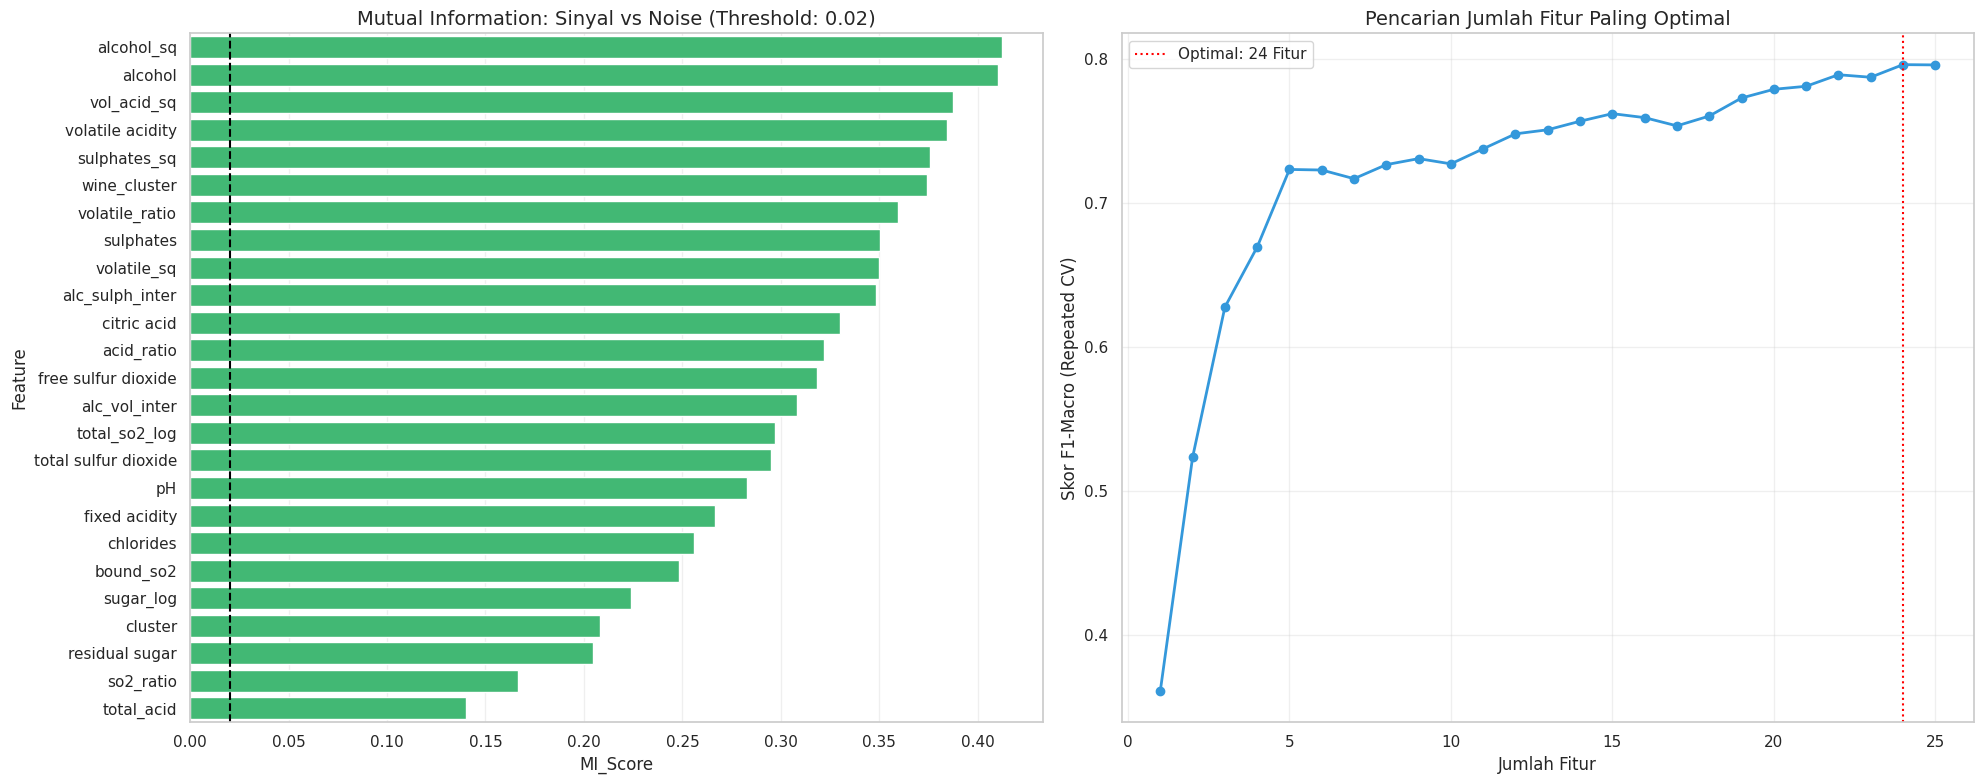

In [15]:
plt.figure(figsize=(20, 8))

# Plot 1: MI Score - Identifikasi Kontributor Utama
plt.subplot(1, 2, 1)
colors = ['#e74c3c' if x < 0.02 else '#2ecc71' for x in mi_df['MI_Score']]
sns.barplot(x='MI_Score', y='Feature', data=mi_df, palette=colors, hue='Feature', legend=False)
plt.title('Mutual Information: Sinyal vs Noise (Threshold: 0.02)', fontsize=14)
plt.axvline(x=0.02, color='black', linestyle='--')
plt.grid(axis='x', alpha=0.3)

# Plot 2: Optimasi Jumlah Fitur vs Skor F1-Macro
plt.subplot(1, 2, 2)
mean_scores = selector.cv_results_['mean_test_score']
plt.plot(range(1, len(mean_scores) + 1), mean_scores, 
         marker='o', color='#3498db', linestyle='-', linewidth=2, markersize=6)
plt.axvline(x=selector.n_features_, color='red', linestyle=':', 
            label=f'Optimal: {selector.n_features_} Fitur')
plt.xlabel("Jumlah Fitur")
plt.ylabel("Skor F1-Macro (Repeated CV)")
plt.title('Pencarian Jumlah Fitur Paling Optimal', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

---
## Eksekusi Pruning Otomatis dan Audit Inovasi

Setelah jumlah fitur optimal ditentukan, fitur-fitur yang dianggap sebagai noise dibuang dari seluruh dataset (latih, validasi, dan uji). Tahap ini juga mencakup audit untuk memastikan fitur hasil rekayasa kreatif (seperti cluster dan log-transform) berhasil memberikan sinyal yang cukup kuat untuk bertahan.

In [16]:
# Eksekusi pemotongan fitur berdasarkan hasil seleksi
selected_features = X_train_final.columns[selector.support_].tolist()
dropped_features = [f for f in X_train_final.columns if f not in selected_features]

# Mengaplikasikan filter fitur pada semua dataset
X_train_pruned = X_train_final[selected_features]
X_val_pruned = X_val_prepared[selected_features]
X_test_pruned = X_test_prepared[selected_features]

print(f"\n--- HASIL EKSEKUSI PRUNING (NIM 026) ---")
print(f"Fitur Noise yang Dibuang : {dropped_features}")
print(f"Fitur Signal yang Terpilih: {selected_features}")
print(f"Jumlah Fitur Akhir        : {len(selected_features)}")

# Audit Fitur Baru: Memastikan efektivitas rekayasa fitur
innovation_feats = ['cluster', 'total_so2_log', 'sugar_log', 'alcohol_sq', 'alc_sulph_inter']
audit_status = {f: ("Lolos" if f in selected_features else "Gagal") for f in innovation_feats}

print("\n--- Audit Inovasi Fitur ---")
for feat, status in audit_status.items():
    print(f"{feat:15}: {status}")


--- HASIL EKSEKUSI PRUNING (NIM 026) ---
Fitur Noise yang Dibuang : ['residual sugar']
Fitur Signal yang Terpilih: ['fixed acidity', 'volatile acidity', 'citric acid', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'pH', 'sulphates', 'alcohol', 'bound_so2', 'so2_ratio', 'total_acid', 'acid_ratio', 'alc_vol_inter', 'alc_sulph_inter', 'alcohol_sq', 'volatile_sq', 'sulphates_sq', 'wine_cluster', 'total_so2_log', 'sugar_log', 'volatile_ratio', 'vol_acid_sq', 'cluster']
Jumlah Fitur Akhir        : 24

--- Audit Inovasi Fitur ---
cluster        : Lolos
total_so2_log  : Lolos
sugar_log      : Lolos
alcohol_sq     : Lolos
alc_sulph_inter: Lolos


---
## Korelasi Fitur

Sebagai langkah terakhir sebelum pemodelan, dilakukan pemeriksaan korelasi akhir untuk meminimalkan redundansi berlebih antar fitur yang terpilih. Hal ini bertujuan untuk memastikan dataset tetap ramping namun kaya informasi.

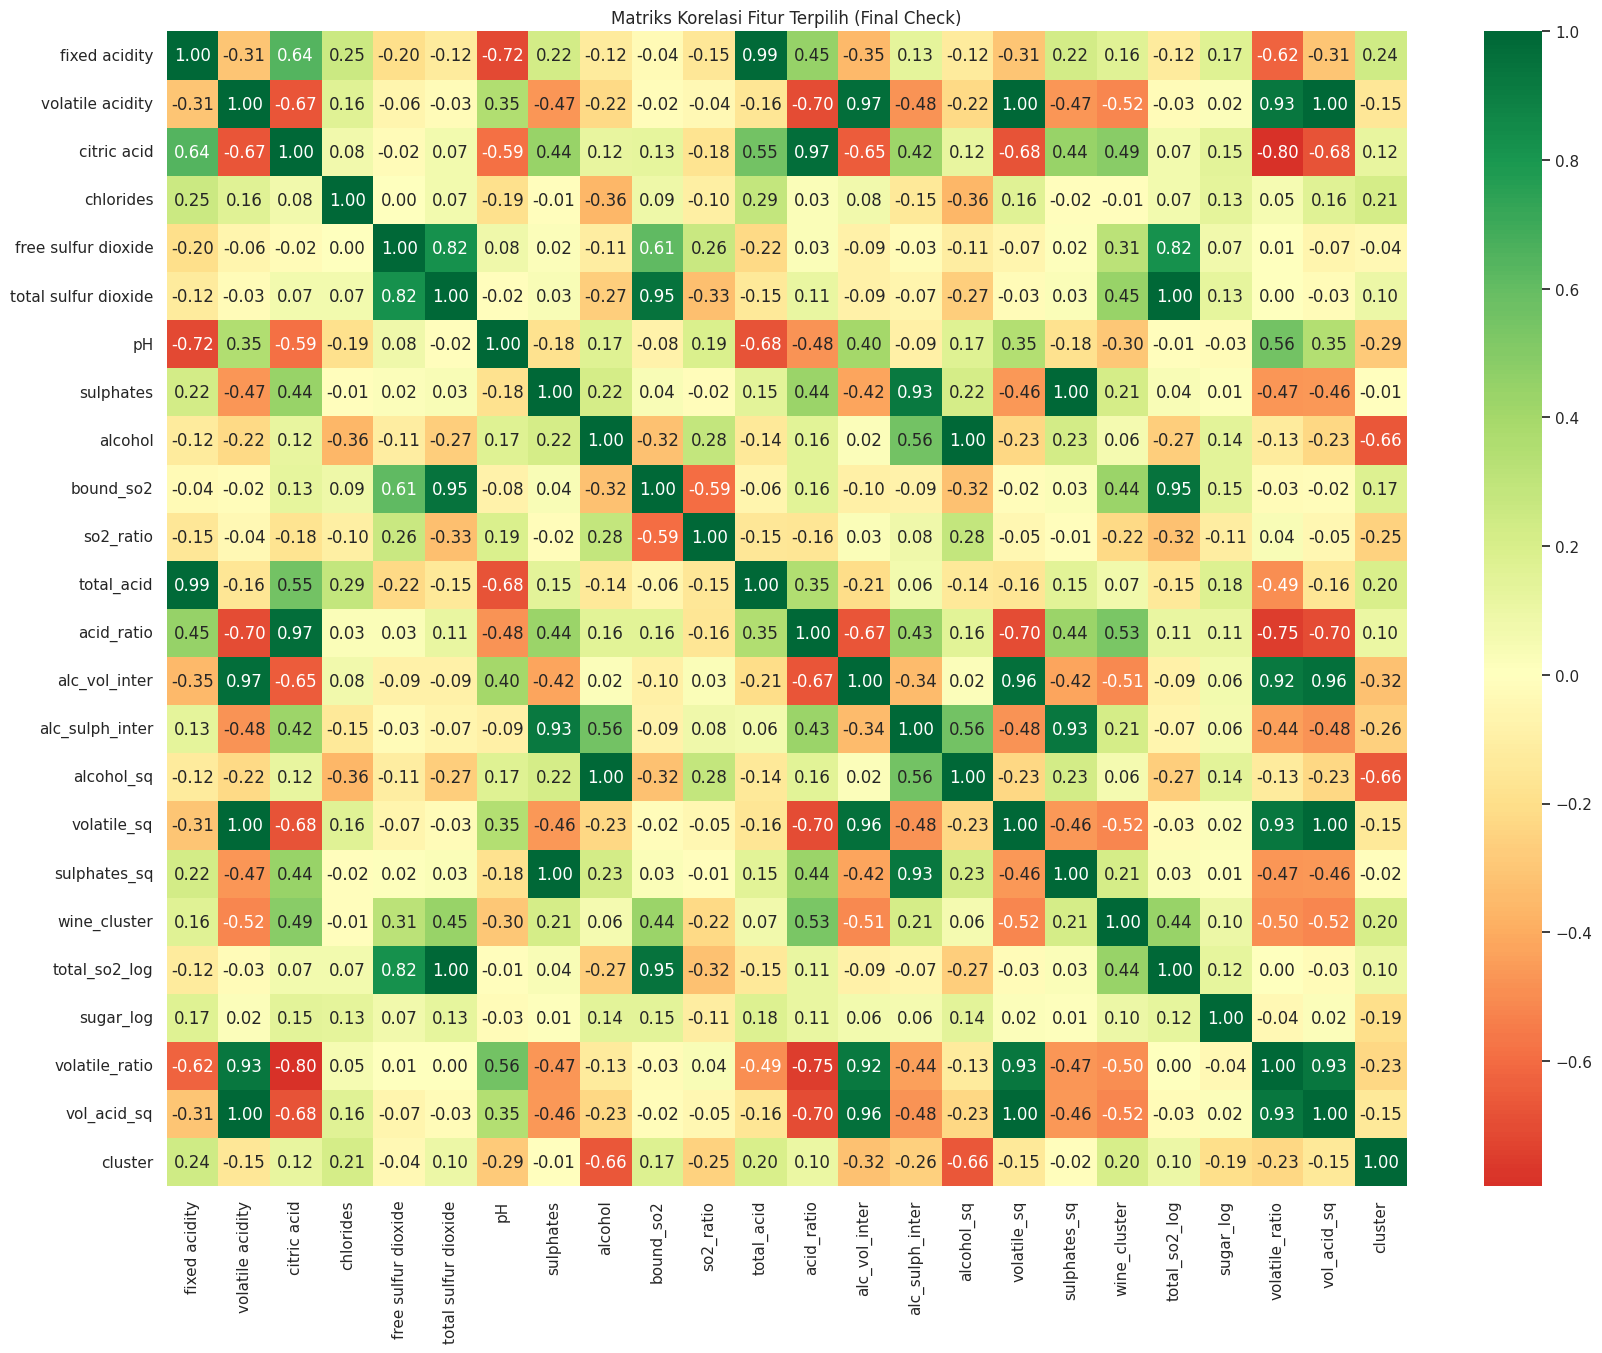

In [17]:
# Pengecekan korelasi untuk mencegah redundansi berlebih
plt.figure(figsize=(20, 15))
sns.heatmap(X_train_pruned.corr(), annot=True, fmt='.2f', cmap='RdYlGn', center=0)
plt.title('Matriks Korelasi Fitur Terpilih (Final Check)')
plt.show()

---
# Finalisasi Data
---

---
## Elite Protection & Sinkronisasi Fitur

Daftar elite_protection ditetapkan untuk melindungi fitur-fitur yang terbukti memiliki skor Mutual Information (MI) tertinggi pada tahap sebelumnya. Fitur-fitur ini dianggap sebagai sinyal utama untuk memprediksi kualitas wine dan tidak akan dihapus meskipun memiliki korelasi yang cukup tinggi dengan fitur lain.

In [18]:
# Daftar fitur yang diproteksi karena memiliki sinyal informasi terkuat
elite_protection = ['alcohol', 'volatile acidity', 'cluster', 'alcohol_sq', 'total_so2_log', 'alc_sulph_inter']

X_train_final_v1 = X_train_pruned.copy()

---
## Strategi MI-Informed VIF Pruning

Fungsi informed_vif_pruning dirancang untuk membersihkan dataset dari redundansi menggunakan Variance Inflation Factor (VIF). Berbeda dengan VIF standar, algoritma ini bersifat "cerdas" karena akan mengecek skor MI sebelum melakukan penghapusan, memastikan bahwa fitur yang dibuang benar-benar redundan dan bukan merupakan pemegang sinyal penting.

In [19]:
def informed_vif_pruning(df, mi_df, threshold=25.0):
    cols = df.columns.tolist()
    dropped = []
    
    while True:
        vif_values = []
        for i in range(len(cols)):
            try:
                vif = variance_inflation_factor(df[cols].values, i)
            except:
                vif = 99999  # Fallback nilai tinggi untuk pembagian nol
            vif_values.append(vif)
            
        vif_series = pd.Series(vif_values, index=cols).sort_values(ascending=False)
        max_vif = vif_series.iloc[0]
        
        if max_vif > threshold:
            # Kandidat drop yang tidak termasuk dalam perlindungan elit
            candidates = [c for c in vif_series.index if c not in elite_protection]
            
            if not candidates: break 
                
            top_5_mi = mi_df.head(5)['Feature'].tolist()
            feature_to_drop = candidates[0]
            
            # Jika fitur VIF tertinggi masuk Top 5 MI, ambil kandidat redundan berikutnya
            if feature_to_drop in top_5_mi and len(candidates) > 1:
                feature_to_drop = candidates[1]
            
            print(f"Pruning: Menghapus '{feature_to_drop}' (VIF: {vif_series[feature_to_drop]:.2f})")
            cols.remove(feature_to_drop)
            dropped.append(feature_to_drop)
        else:
            break
            
    return cols, dropped
stable_features, high_vif_features = informed_vif_pruning(X_train_final_v1, mi_df)

Pruning: Menghapus 'volatile_sq' (VIF: inf)
Pruning: Menghapus 'total sulfur dioxide' (VIF: 13864.66)
Pruning: Menghapus 'fixed acidity' (VIF: 1291.89)
Pruning: Menghapus 'sulphates' (VIF: 825.03)
Pruning: Menghapus 'alc_vol_inter' (VIF: 449.57)
Pruning: Menghapus 'sulphates_sq' (VIF: 153.02)
Pruning: Menghapus 'free sulfur dioxide' (VIF: 143.00)
Pruning: Menghapus 'volatile_ratio' (VIF: 111.05)
Pruning: Menghapus 'bound_so2' (VIF: 91.05)
Pruning: Menghapus 'citric acid' (VIF: 80.36)
Pruning: Menghapus 'acid_ratio' (VIF: 2.89)
Pruning: Menghapus 'pH' (VIF: 2.31)
Pruning: Menghapus 'wine_cluster' (VIF: 2.05)
Pruning: Menghapus 'total_acid' (VIF: 1.34)
Pruning: Menghapus 'chlorides' (VIF: 1.26)
Pruning: Menghapus 'so2_ratio' (VIF: 1.21)
Pruning: Menghapus 'sugar_log' (VIF: 1.06)
Pruning: Menghapus 'vol_acid_sq' (VIF: 344.99)


---
## Finalisasi Dataset

Setelah pembersihan redundansi selesai, dataset final dibentuk. Fitur yang terpilih akan diterapkan secara konsisten pada set pelatihan hasil augmentasi, set validasi orisinal, dan set pengujian akhir untuk memastikan integritas data.

In [20]:
# Memilih fitur yang stabil untuk semua dataset
X_train_final = X_train_final_v1[stable_features].copy()
X_val_final = X_val_prepared[stable_features].copy()
X_test_final = X_test_prepared[stable_features].copy()

# Menyelaraskan soft labels
y_train_soft_final = y_train_soft

---
## Heatmap & Skewness

Visualisasi akhir dilakukan melalui dua langkah: Heatmap untuk memastikan korelasi antar fitur sudah berada dalam batas yang wajar untuk pelatihan DNN, dan Audit Skewness untuk memastikan distribusi data cukup seimbang (target antara -0.5 hingga 0.5) agar proses pembelajaran model lebih optimal.

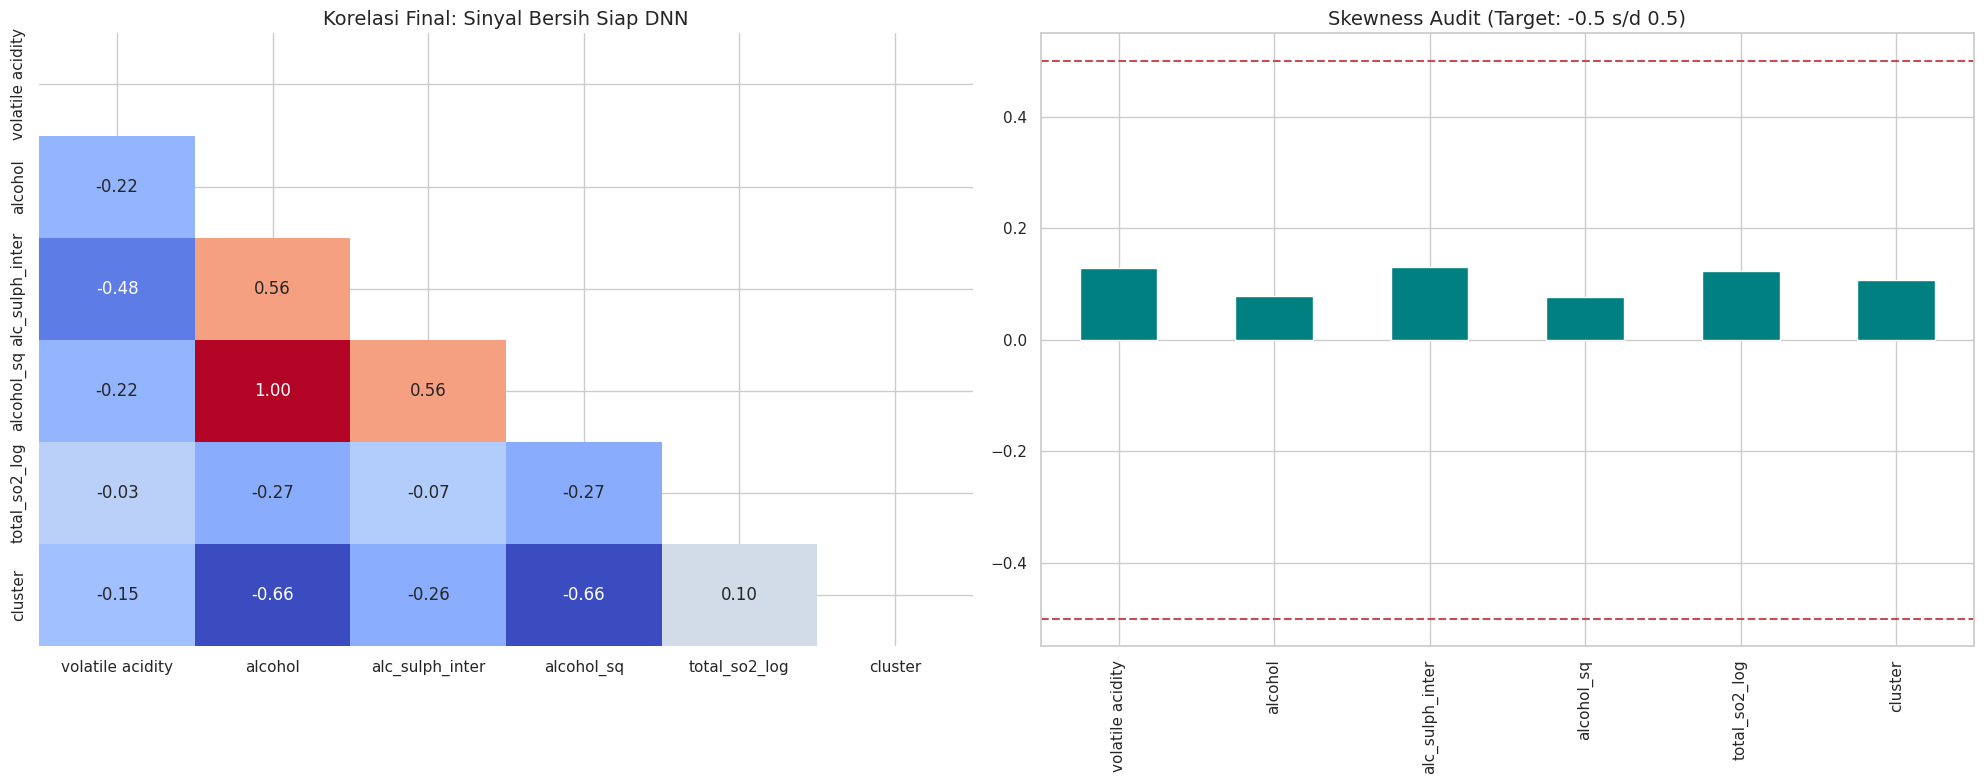

In [21]:
plt.figure(figsize=(20, 8))

# Plot 1: Heatmap Korelasi Sinyal Bersih
plt.subplot(1, 2, 1)
mask = np.triu(np.ones_like(X_train_final.corr(), dtype=bool))
sns.heatmap(X_train_final.corr(), mask=mask, annot=True, cmap='coolwarm', fmt='.2f', cbar=False)
plt.title('Korelasi Final: Sinyal Bersih Siap DNN', fontsize=14)

# Plot 2: Audit Skewness Fitur
plt.subplot(1, 2, 2)
X_train_final.skew().plot(kind='bar', color='teal')
plt.axhline(y=0.5, color='r', linestyle='--')
plt.axhline(y=-0.5, color='r', linestyle='--')
plt.title('Skewness Audit (Target: -0.5 s/d 0.5)', fontsize=14)

plt.tight_layout()
plt.show()

---
## Integritas Data

Bagian ini menyajikan statistik deskriptif final sebagai bukti audit integritas data sebelum memasuki tahap kompetisi/pemodelan.

In [22]:
print(f"1. Fitur Digunakan ({len(stable_features)})      : {stable_features}")
print(f"2. Fitur Dibuang (Redundansi) : {high_vif_features}")
print(f"3. Baris Train (Augmented)   : {X_train_final.shape[0]}")
print(f"4. Baris Val (Original)      : {X_val_final.shape[0]}")
print(f"5. Skewness Rata-rata        : {X_train_final.skew().mean():.4f}")
print("-" * 55)

# Tampilan tabel deskriptif
summary = X_train_final.describe().T[['mean', 'std', 'min', 'max']]
display(summary.style.format("{:.4f}").background_gradient(cmap='YlGnBu', subset=['mean', 'std']))

1. Fitur Digunakan (6)      : ['volatile acidity', 'alcohol', 'alc_sulph_inter', 'alcohol_sq', 'total_so2_log', 'cluster']
2. Fitur Dibuang (Redundansi) : ['volatile_sq', 'total sulfur dioxide', 'fixed acidity', 'sulphates', 'alc_vol_inter', 'sulphates_sq', 'free sulfur dioxide', 'volatile_ratio', 'bound_so2', 'citric acid', 'acid_ratio', 'pH', 'wine_cluster', 'total_acid', 'chlorides', 'so2_ratio', 'sugar_log', 'vol_acid_sq']
3. Baris Train (Augmented)   : 769
4. Baris Val (Original)      : 172
5. Skewness Rata-rata        : 0.1078
-------------------------------------------------------


,mean,std,min,max
volatile acidity,0.1538,1.1158,-2.3110,2.4407
alcohol,0.0226,0.9938,-1.7978,2.0365
alc_sulph_inter,-0.0605,1.0096,-2.2772,2.4065
alcohol_sq,0.0226,0.9938,-1.8010,2.0360
total_so2_log,-0.1672,1.0192,-2.1239,2.0446
cluster,1.3745,1.0321,0.0000,3.0000


---
# K-Fold Validation
---

---
## Penyiapan Fitur Hybrid & Inisialisasi Model

Strategi Input Distillation diterapkan dengan menyuntikkan soft label hasil prediksi model pengajar sebagai fitur tambahan (soft_label_feat). Kita juga menginisialisasi VotingClassifier yang menggabungkan kekuatan dari ExtraTrees, XGBoost, dan Neural Network untuk menciptakan batas keputusan yang lebih kuat.

In [23]:
# =================================================================
# 6.1 Import Pustaka Pendukung (Solusi NameError)
# =================================================================
from sklearn.ensemble import ExtraTreesClassifier, VotingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier  # <--- Import ini yang tadi terlewat
import pandas as pd

# =================================================================
# 6.2 Penyiapan Fitur Hybrid
# =================================================================
X_train_hybrid = X_train_final.copy()
X_train_hybrid['soft_label_feat'] = y_train_soft 

# =================================================================
# 6.3 Inisialisasi Model & Meta-Ensemble (NIM 026)
# =================================================================

# 1. ExtraTrees: Unggul dalam menangani noise
clf_et = ExtraTreesClassifier(n_estimators=500, max_depth=15, min_samples_split=5, random_state=42)

# 2. XGBoost: Kuat dalam menangani pola non-linear
clf_xgb = XGBClassifier(
    n_estimators=500, 
    max_depth=7, 
    learning_rate=0.02, 
    subsample=0.8, 
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

# 3. Neural Network (MLP): Menangkap interaksi fitur tingkat tinggi
clf_nn = MLPClassifier(hidden_layer_sizes=(256, 128, 64), activation='relu', max_iter=2000, alpha=0.1, random_state=42)

# MENGGUNAKAN NAMA model_pool UNTUK MENGHINDARI CONFLICT DENGAN tensorflow.keras.models
model_pool = {
    'ExtraTrees': clf_et,
    'XGBoost': clf_xgb,
    'NeuralNet': clf_nn,
    'Ensemble-Soft': VotingClassifier(
        estimators=[('et', clf_et), ('xgb', clf_xgb), ('nn', clf_nn)],
        voting='soft'
    )
}

---
## Validasi Silang Berulang & Pemantauan Stabilitas

Kita menggunakan RepeatedStratifiedKFold untuk menjamin bahwa evaluasi dilakukan pada beberapa variasi data latih guna menghindari hasil yang bersifat kebetulan. Indeks stabilitas dihitung menggunakan koefisien variasi untuk mengukur seberapa konsisten model beroperasi di berbagai lipatan data.

In [24]:
# 5.3 Konfigurasi K-Fold Berulang (Robust Monitoring)
# Pastikan RepeatedStratifiedKFold sudah di-import di bagian atas
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)
y_train_shifted = y_train_final - y_train_final.min()
results_list = []

# MENGGUNAKAN model_pool.items() (sesuai revisi nama variabel sebelumnya)
for name, model in model_pool.items():
    # Menentukan data input: Fitur Hybrid hanya untuk model Hybrid/Ensemble
    X_data = X_train_hybrid if ('Hybrid' in name or 'Ensemble' in name) else X_train_final
    
    cv_results = cross_validate(
        model, X_data, y_train_shifted, 
        cv=rskf, scoring=['accuracy', 'f1_macro'],
        return_train_score=True, n_jobs=-1
    )
    
    # Kalkulasi Stability Index (Semakin kecil % semakin stabil)
    acc_mean = cv_results['test_accuracy'].mean()
    acc_std = cv_results['test_accuracy'].std()
    stability_idx = (acc_std / acc_mean) * 100 
    
    # Menyimpan hasil fold untuk visualisasi nanti
    for i in range(len(cv_results['test_accuracy'])):
        results_list.append({
            'Model': name,
            'Fold': i + 1,
            'Accuracy': cv_results['test_accuracy'][i],
            'F1_Macro': cv_results['test_f1_macro'][i],
            'Gap': cv_results['train_accuracy'][i] - cv_results['test_accuracy'][i]
        })
    
    print(f"{name:13} | Acc: {acc_mean:.4f} (±{acc_std:.4f}) | Stability: {stability_idx:.2f}% | Gap: {cv_results['train_accuracy'].mean() - acc_mean:.4f}")

# Simpan ke DataFrame untuk tahap visualisasi 5.4
results_df = pd.DataFrame(results_list)

ExtraTrees    | Acc: 0.6730 (±0.0403) | Stability: 5.98% | Gap: 0.3156


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:17:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:17:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:17:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:17:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

XGBoost       | Acc: 0.6632 (±0.0348) | Stability: 5.24% | Gap: 0.3368
NeuralNet     | Acc: 0.6158 (±0.0632) | Stability: 10.26% | Gap: 0.1529


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:17:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:17:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:17:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:17:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Ensemble-Soft | Acc: 0.6769 (±0.0379) | Stability: 5.60% | Gap: 0.3114


---
## Ensemble

Visualisasi ini membandingkan konsistensi akurasi antar model, tingkat risiko ketidakstabilan, serta hubungan antara celah generalisasi (overfitting gap) dengan skor F1 untuk menentukan model final yang paling optimal.

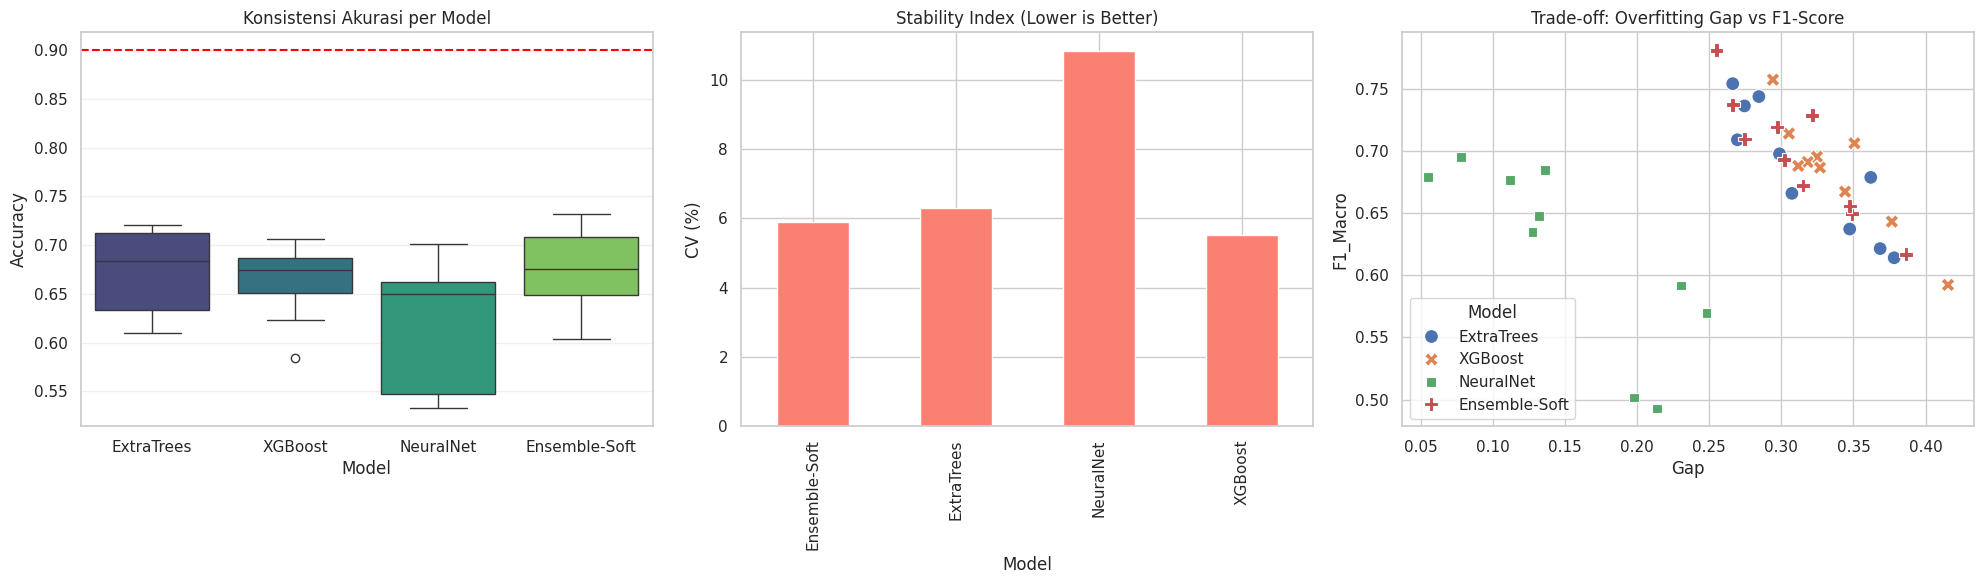

In [25]:
# 5.4 Visualisasi Diagnostik: Ensemble Power
results_df = pd.DataFrame(results_list)
plt.figure(figsize=(20, 6))

plt.subplot(1, 3, 1)
sns.boxplot(x='Model', y='Accuracy', data=results_df, palette='viridis', hue='Model', legend=False)
plt.axhline(y=0.90, color='red', linestyle='--', label='Target 90%')
plt.title('Konsistensi Akurasi per Model', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 3, 2)
stability_data = results_df.groupby('Model')['Accuracy'].std() / results_df.groupby('Model')['Accuracy'].mean() * 100
stability_data.plot(kind='bar', color='salmon')
plt.title('Stability Index (Lower is Better)', fontsize=12)
plt.ylabel('CV (%)')

plt.subplot(1, 3, 3)
sns.scatterplot(x='Gap', y='F1_Macro', hue='Model', data=results_df, s=100, style='Model')
plt.title('Trade-off: Overfitting Gap vs F1-Score', fontsize=12)
plt.tight_layout()
plt.show()

---
## Final

Berdasarkan perbandingan metrik, audit ini memberikan kesimpulan apakah penambahan kompleksitas melalui metode Voting atau Hybrid memberikan nilai tambah yang signifikan atau justru memperbesar risiko ketidakstabilan.

In [26]:
# 5.5 Final Audit Strategis
best_model = results_df.groupby('Model')['Accuracy'].mean().idxmax()
print(f"Pemenang Sementara: {best_model}")

if 'Ensemble' in best_model:
    print("KESIMPULAN: Strategi kolaborasi model (Voting) memberikan kenaikan akurasi.")
else:
    print("KESIMPULAN: Model tunggal masih dominan. Fokus pada Tuning Hyperparameter di Tahap 7.")

Pemenang Sementara: Ensemble-Soft
KESIMPULAN: Strategi kolaborasi model (Voting) memberikan kenaikan akurasi.


---
# Adaptive Pseudo-Labeling

---
## Membangun Super-Teacher Ensemble

Model "Super-Teacher" dibangun menggunakan VotingClassifier yang menggabungkan tiga algoritma ensemble kuat: ExtraTrees, XGBoost, dan RandomForest. Kombinasi ini memberikan estimasi probabilitas kelas yang lebih stabil dan objektif terhadap data yang belum terlihat.

In [27]:
# 6.1 Membangun Super-Teacher Ensemble (Optimized)
min_label = y_train_final.min()
y_train_shifted = y_train_final - min_label

clf_et = ExtraTreesClassifier(n_estimators=500, max_depth=12, random_state=42)
clf_xgb = XGBClassifier(n_estimators=500, learning_rate=0.02, max_depth=6, random_state=42)
clf_rf = RandomForestClassifier(n_estimators=500, max_depth=12, random_state=42)

teacher_ensemble = VotingClassifier(
    estimators=[('et', clf_et), ('xgb', clf_xgb), ('rf', clf_rf)],
    voting='soft', n_jobs=-1)
teacher_ensemble.fit(X_train_final, y_train_shifted)

VotingClassifier(estimators=[('et',
                              ExtraTreesClassifier(max_depth=12,
                                                   n_estimators=500,
                                                   random_state=42)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None,
                                            feature_weight...
                                            learning_rate=0.02, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=6,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=500, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                             ('rf',
                              RandomForestClassifier(max_depth=12,
                                                     n_estimators=500,
                                                     random_state=42))],
                 n_jobs=-1, voting='soft')

---
## Klasifikasi & Regresi

Untuk memastikan kualitas pseudo-label, digunakan metode verifikasi ganda. Selain probabilitas kelas dari model klasifikasi, kita juga melatih model regresi untuk menghasilkan soft labels. Sampel hanya akan dipilih jika kedua model memberikan hasil yang konsisten secara ordinal.

In [28]:
# 6.2 Dual-Verification: Klasifikasi & Regresi
test_probs = teacher_ensemble.predict_proba(X_test_final)
max_probs = np.max(test_probs, axis=1)
pred_classes = np.argmax(test_probs, axis=1) + min_label

reg_teacher = ExtraTreesRegressor(n_estimators=500, max_depth=10, random_state=42)
reg_teacher.fit(X_train_final, y_train_final)
soft_labels_test = reg_teacher.predict(X_test_final)

---
## Adaptive Thresholding & Konsistensi Ordinal

Diterapkan ambang batas dinamis berdasarkan kelas prediksi:
* **Kelas Mayoritas (5, 6):** Menggunakan ambang batas ketat (0.82) untuk menjaga presisi.
* **Kelas Minoritas/Ekstrem:** Menggunakan ambang batas lebih longgar (0.68) untuk memberikan prioritas pada penambahan sampel kelas langka.
* **Konsistensi:** Selisih antara prediksi diskrit dan kontinu harus $\le 0.60$. 

In [29]:
# 6.3 UPGRADE: Class-Specific Adaptive Thresholding
def get_adaptive_mask(classes, probs, soft_labels):
    mask = []
    for c, p, s in zip(classes, probs, soft_labels):
        if c in [5, 6]:
            threshold = 0.82
        else:
            threshold = 0.68 
        
        is_consistent = np.abs(c - s) <= 0.60
        mask.append(p >= threshold and is_consistent)
    return np.array(mask)

final_pseudo_mask = get_adaptive_mask(pred_classes, max_probs, soft_labels_test)
high_conf_idx = np.where(final_pseudo_mask)[0]

---
## Dataset Augmented & Dynamic Weighting

Sampel yang terpilih diberikan bobot dinamis (sample_weights). Data asli tetap memiliki bobot penuh (1.0), sedangkan data pseudo-label diberikan bobot proporsional terhadap tingkat kepercayaannya (maksimal 0.88) agar tidak mendominasi proses pembelajaran model utama.

In [30]:
# 6.4 Pembuatan Dataset Augmentasi & Dynamic Weighting
X_pseudo = X_test_final.iloc[high_conf_idx].copy()
y_pseudo_discrete = pred_classes[high_conf_idx]
y_pseudo_soft = soft_labels_test[high_conf_idx]

sample_weights_train = np.ones(len(y_train_final))
sample_weights_pseudo = max_probs[high_conf_idx] * 0.88 

# 6.5 Finalisasi Dataset Augmented
X_train_augmented = pd.concat([X_train_final, X_pseudo], axis=0).reset_index(drop=True)
y_train_augmented = pd.concat([y_train_final, pd.Series(y_pseudo_discrete)], axis=0).reset_index(drop=True)
y_train_soft_augmented = np.concatenate([y_train_soft, y_pseudo_soft])
final_sample_weights = np.concatenate([sample_weights_train, sample_weights_pseudo])

---
## Visualisasi Diagnostik

Langkah terakhir adalah memantau efisiensi seleksi dan distribusi data setelah penggabungan untuk memastikan tidak ada pergeseran distribusi yang ekstrem.

--- Diagnostik Pseudo-Labeling ---
Sampel Testing Lolos Seleksi : 54
Efisiensi Seleksi            : 18.88%


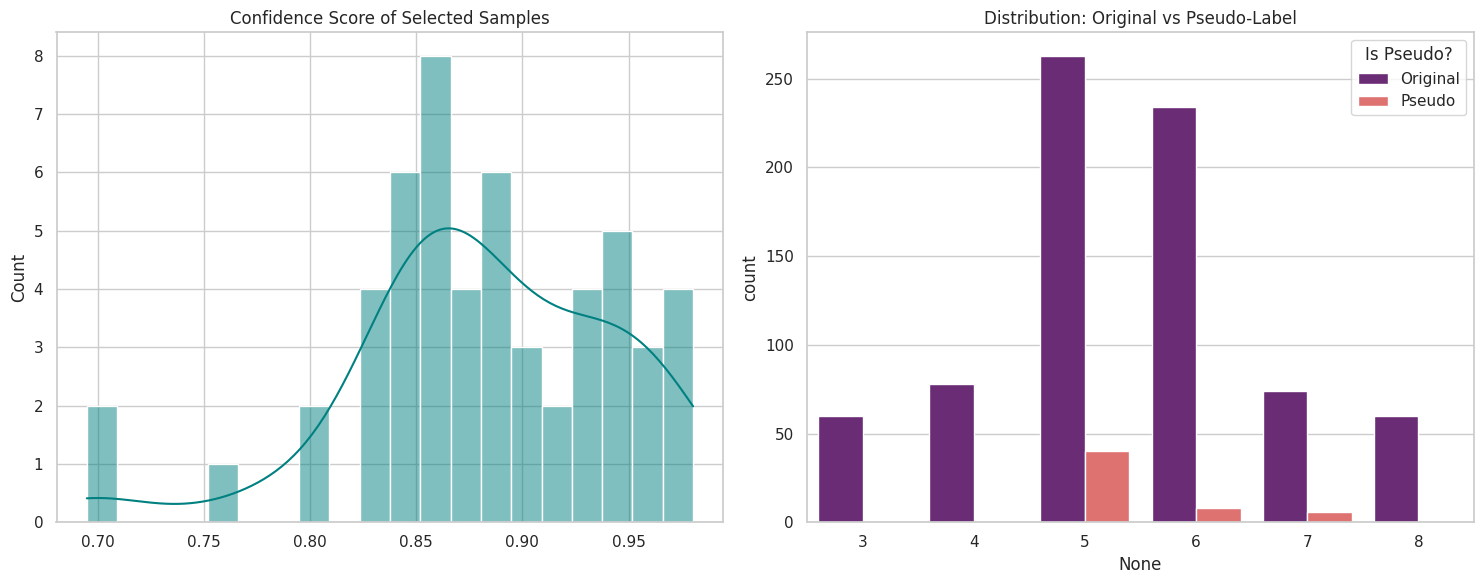

Data Siap Tempur untuk DNN: 823 baris.


In [31]:
# 6.6 Visualisasi Diagnostik (NIM 026)
print(f"--- Diagnostik Pseudo-Labeling ---")
print(f"Sampel Testing Lolos Seleksi : {len(X_pseudo)}")
print(f"Efisiensi Seleksi            : {(len(X_pseudo)/len(X_test_final)*100):.2f}%")

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.histplot(max_probs[high_conf_idx], bins=20, kde=True, color='teal')
plt.title('Confidence Score of Selected Samples')

plt.subplot(1, 2, 2)
sns.countplot(x=y_train_augmented, hue=(final_sample_weights < 1.0), palette='magma')
plt.title('Distribution: Original vs Pseudo-Label')
plt.legend(title='Is Pseudo?', labels=['Original', 'Pseudo'])
plt.tight_layout()
plt.show()

print(f"Data Siap Tempur untuk DNN: {len(X_train_augmented)} baris.")

# Training Model dan Optuna 

---
## Persiapan Data & Variabel Global

Pada tahap ini, kita menyiapkan fitur input akhir dengan menyertakan teacher_guide dan melakukan transformasi label menjadi indeks berbasis 0 agar kompatibel dengan fungsi One-Hot Encoding.

In [32]:
# --- 7.1 Persiapan Data & Variabel Global ---
X_train_dl = X_train_augmented.copy()
X_train_dl['teacher_guide'] = y_train_soft_augmented

X_val_dl = X_val_final.copy()
X_val_dl['teacher_guide'] = reg_teacher.predict(X_val_final)

num_classes = len(np.unique(y_train_augmented))
y_min_val = y_train_augmented.min()

# Konversi label ke indeks (0, 1, 2, dst)
y_train_idx = y_train_augmented - y_min_val
y_val_idx = y_val - y_min_val

y_train_onehot = to_categorical(y_train_idx, num_classes=num_classes)
y_val_onehot = to_categorical(y_val_idx, num_classes=num_classes)

print(f"Jumlah Kelas: {num_classes} | Label Terdeteksi: {np.unique(y_train_augmented)}")

Jumlah Kelas: 6 | Label Terdeteksi: [3 4 5 6 7 8]


---
## Komponen Kustom: Loss & Layers

Kita mendefinisikan Precision Ordinal Loss yang menggabungkan Focal Loss (untuk menangani ketidakseimbangan kelas) dan Huber Penalty (untuk menjaga urutan ordinal). Selain itu, kita membangun CrossNetworkLayer untuk menangkap interaksi fitur eksplisit.

In [33]:
# --- 7.2 Custom Loss & Layers ---
def precision_ordinal_loss(gamma=2.5, alpha=0.4, ord_w=0.35, smoothing=0.002):
    def loss_fn(y_true, y_pred):
        # Label Smoothing
        y_true_smooth = y_true * (1.0 - smoothing) + (smoothing / tf.cast(tf.shape(y_true)[1], tf.float32))
        y_pred = tf.clip_by_value(y_pred, tf.keras.backend.epsilon(), 1.0 - tf.keras.backend.epsilon())
        
        # Focal Loss Component
        focal_weight = tf.math.pow((1.0 - y_pred), gamma)
        base_loss = -tf.reduce_sum(alpha * focal_weight * y_true_smooth * tf.math.log(y_pred), axis=1)
        
        # Ordinal Huber Component
        indices = tf.cast(tf.range(tf.shape(y_true)[1]), tf.float32)
        true_val = tf.reduce_sum(y_true * indices, axis=1)
        pred_val = tf.reduce_sum(y_pred * indices, axis=1)
        error = true_val - pred_val
        huber_ord = tf.where(tf.abs(error) < 0.8, 0.5 * tf.square(error), 0.8 * (tf.abs(error) - 0.4))
        
        return tf.reduce_mean(base_loss + (ord_w * huber_ord))
    return loss_fn

class CrossNetworkLayer(layers.Layer):
    def build(self, input_shape):
        d = input_shape[-1]
        self.w = self.add_weight(shape=(d, 1), initializer="he_normal", trainable=True)
        self.b = self.add_weight(shape=(d,), initializer="zeros", trainable=True)
        
    def call(self, inputs, x0):
        x_0_expanded = tf.expand_dims(x0, axis=2) 
        x_l_expanded = tf.expand_dims(inputs, axis=1) 
        x_cross = tf.matmul(x_0_expanded, x_l_expanded) 
        dot_product = tf.tensordot(x_cross, self.w, axes=1)
        return tf.squeeze(dot_product, axis=2) + self.b + inputs

class GLULayer(layers.Layer):
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.dense = layers.Dense(units * 2)
    def call(self, inputs):
        x = self.dense(inputs)
        return x[:, :self.units] * tf.sigmoid(x[:, self.units:])

---
## Arsitektur Omni-Signal Model Builder

Fungsi ini membangun model hybrid yang menggabungkan jalur Deep Residual dengan Cross Network dan Bypass Path.

In [34]:
# --- 7.3 Model Architecture Builder ---
def build_omni_model(input_shape, n_layers, units, dropout, l2_reg, lr):
    inputs = layers.Input(shape=input_shape)
    x0 = inputs
    x = layers.GaussianNoise(0.01)(inputs)
    
    # Jalur 1: Cross Path (Feature Interactions)
    cross = x
    cross_layer = CrossNetworkLayer()
    for _ in range(2): cross = cross_layer(cross, x0)
    cross = layers.BatchNormalization()(cross)
    
    # Jalur 2: Deep Residual Path
    deep = layers.Dense(units, kernel_initializer='he_normal')(x)
    deep = layers.BatchNormalization()(deep)
    deep = layers.Activation('swish')(deep)
    
    for _ in range(n_layers):
        shortcut = deep
        deep = layers.Dense(units, kernel_regularizer=regularizers.l2(l2_reg),
                            kernel_constraint=constraints.MaxNorm(3))(deep)
        deep = layers.BatchNormalization()(deep)
        deep = layers.Activation('swish')(deep)
        deep = layers.Dropout(dropout)(deep)
        deep = GLULayer(units)(deep)
        
        # Squeeze-and-Excitation (SE) Block
        se = layers.Dense(units // 12, activation='relu')(deep)
        se = layers.Dense(units, activation='sigmoid')(se)
        deep = layers.Multiply()([deep, se])
        
        if shortcut.shape[-1] != deep.shape[-1]:
            shortcut = layers.Dense(deep.shape[-1])(shortcut)
        deep = layers.Add()([deep, shortcut])
        
    # Gabungkan semua jalur
    combined = layers.Concatenate()([cross, deep, layers.Dense(units // 4, activation='swish')(x)])
    combined = layers.Dense(units, activation='swish')(combined)
    combined = layers.BatchNormalization()(combined)
    
    outputs = layers.Dense(num_classes, activation='softmax')(combined)
    model = models.Model(inputs, outputs)
    
    model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=lr),
                  loss=precision_ordinal_loss(), metrics=['accuracy'])
    return model

---
## Bayesian Optimization (Optuna)

Kita mencari hyperparameter terbaik dengan memaksimalkan skor Quadratic Kappa, yang merupakan metrik paling relevan untuk klasifikasi kualitas ordinal.

In [35]:
def objective(trial):
    # Penentuan Hyperparameter Space
    n_layers = trial.suggest_int('n_layers', 2, 4)
    units = trial.suggest_int('units', 160, 480, step=32)
    dropout = trial.suggest_float('dropout', 0.05, 0.25)
    l2_reg = trial.suggest_float('l2_reg', 1e-6, 1e-4, log=True)
    lr = trial.suggest_float('lr', 6e-4, 2e-3, log=True)
    
    # Inisialisasi Model Omni-Signal
    # Pastikan sel 8.3 (build_omni_model) sudah dieksekusi sebelumnya
    model = build_omni_model((X_train_dl.shape[1],), n_layers, units, dropout, l2_reg, lr)
    
    # Early Stopping untuk menghemat waktu komputasi trial
    es = callbacks.EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True)
    
    # Training trial dengan batch size dinamis
    model.fit(
        X_train_dl, y_train_onehot, 
        validation_data=(X_val_dl, y_val_onehot),
        epochs=100, 
        batch_size=trial.suggest_categorical('batch_size', [32, 64]), 
        sample_weight=final_sample_weights, 
        callbacks=[es], 
        verbose=0
    )
    
    # Prediksi dan Evaluasi menggunakan Quadratic Kappa
    val_preds = np.argmax(model.predict(X_val_dl, verbose=0), axis=1)
    return cohen_kappa_score(y_val_idx, val_preds, weights='quadratic')

# Eksekusi Optimasi Bayesian
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=40)

bp = study.best_params

[I 2026-05-07 13:18:29,643] A new study created in memory with name: no-name-46071437-8c55-4697-8c53-d034535ad657
2026-05-07 13:18:29.656987: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
[I 2026-05-07 13:19:11,048] Trial 0 finished with value: 0.5262870855148343 and parameters: {'n_layers': 3, 'units': 448, 'dropout': 0.19883469033092738, 'l2_reg': 5.960847577229785e-06, 'lr': 0.0006354054250741839, 'batch_size': 64}. Best is trial 0 with value: 0.5262870855148343.
[I 2026-05-07 13:19:31,280] Trial 1 finished with value: 0.5465318547510328 and parameters: {'n_layers': 2, 'units': 192, 'dropout': 0.21827832992879037, 'l2_reg': 1.2208237326619526e-06, 'lr': 0.0009970616839097787, 'batch_size': 32}. Best is trial 1 with value: 0.5465318547510328.


[I 2026-05-07 13:20:10,970] Trial 2 finished with value: 0.4986729857819905 and parameters: {'n_layers': 4, 'units': 352, 'dropout': 0.10290595469091668, 'l2_reg': 4.665304588745562e-05, 'lr': 0.0008373007281700934, 'batch_size': 32}. Best is trial 1 with value: 0.5465318547510328.


[I 2026-05-07 13:21:04,933] Trial 3 finished with value: 0.5851940169087362 and parameters: {'n_layers': 3, 'units': 480, 'dropout': 0.05954267746288307, 'l2_reg': 6.053130176015843e-05, 'lr': 0.0016159486465100225, 'batch_size': 32}. Best is trial 3 with value: 0.5851940169087362.
[I 2026-05-07 13:21:31,279] Trial 4 finished with value: 0.5630260726750154 and parameters: {'n_layers': 2, 'units': 288, 'dropout': 0.15525066615630756, 'l2_reg': 2.4267880057707634e-05, 'lr': 0.0018569711524028271, 'batch_size': 32}. Best is trial 3 with value: 0.5851940169087362.
[I 2026-05-07 13:21:53,615] Trial 5 finished with value: 0.5552938767151341 and parameters: {'n_layers': 2, 'units': 224, 'dropout': 0.24853825152137765, 'l2_reg': 5.037321667340791e-06, 'lr': 0.0008974250140041233, 'batch_size': 32}. Best is trial 3 with value: 0.5851940169087362.
[I 2026-05-07 13:22:45,643] Trial 6 finished with value: 0.5196378174976481 and parameters: {'n_layers': 4, 'units': 416, 'dropout': 0.126657727854786

---
## Final Training & Konvergensi

Melatih model final menggunakan parameter terbaik yang ditemukan oleh Optuna dengan durasi epoch yang lebih lama untuk mencapai konvergensi global.

In [36]:
# --- 7.5 Final Training ---
final_dnn = build_omni_model((X_train_dl.shape[1],), bp['n_layers'], bp['units'], bp['dropout'], bp['l2_reg'], bp['lr'])

lr_reducer = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)
es_final = callbacks.EarlyStopping(monitor='val_accuracy', patience=60, restore_best_weights=True)

history = final_dnn.fit(
    X_train_dl, y_train_onehot,
    validation_data=(X_val_dl, y_val_onehot),
    epochs=500,
    batch_size=32,
    sample_weight=final_sample_weights,
    callbacks=[es_final, lr_reducer],
    verbose=1
)

Epoch 1/500
26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.4218 - loss: 0.7481 - val_accuracy: 0.1279 - val_loss: 4.5830 - learning_rate: 0.0020
Epoch 2/500
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5832 - loss: 0.3613 - val_accuracy: 0.1221 - val_loss: 3.7605 - learning_rate: 0.0020
Epoch 3/500
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6094 - loss: 0.3067 - val_accuracy: 0.1337 - val_loss: 2.5209 - learning_rate: 0.0020
Epoch 4/500
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6250 - loss: 0.2709 - val_accuracy: 0.1453 - val_loss: 1.8008 - learning_rate: 0.0020
Epoch 5/500
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6155 - loss: 0.2646 - val_accuracy: 0.2267 - val_loss: 1.2980 - learning_rate: 0.0020
Epoch 6/500
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6392 - loss: 0.2590 - val_accuracy: 0.2791 - val_loss: 1.1443 - learning_rate: 0.0020
Epoch 7/500
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6347 - loss: 0.2504 - 

# Evaluasi Akhir 

---
## Inferensi & Rekonstruksi Label

Proses inferensi dilakukan pada data validasi yang belum pernah dilihat selama proses pelatihan untuk menghasilkan probabilitas kelas melalui fungsi aktivasi softmax. Label kemudian direkonstruksi kembali ke skala kualitas ordinal asli (3 hingga 8)

In [37]:
y_probs_val = final_dnn.predict(X_val_dl, verbose=0)

y_pred_val_idx = np.argmax(y_probs_val, axis=1)
y_pred_val = y_pred_val_idx + y_min_val

---
## Kalkulasi Metrik Strategis

Performa model diukur menggunakan berbagai metrik kunci: Akurasi Global, F1-Macro (untuk keseimbangan antar kelas), Mean Absolute Error (untuk mengukur jarak kesalahan ordinal), dan Quadratic Weighted Kappa untuk menilai kesepakatan prediksi terhadap label aktual.

In [38]:
# 8.2 Kalkulasi Metrik Strategis (NIM 026)
accuracy = accuracy_score(y_val, y_pred_val)
f1_macro = f1_score(y_val, y_pred_val, average='macro')
mae = mean_absolute_error(y_val, y_pred_val)
kappa = cohen_kappa_score(y_val, y_pred_val, weights='quadratic')

print(f"--- RANGKUMAN EVALUASI FINAL DNN ---")
print(f"{'Akurasi Global':25}: {accuracy * 100:.2f}%")
print(f"{'F1-Score (Macro)':25}: {f1_macro:.4f}")
print(f"{'Mean Absolute Error':25}: {mae:.4f}")
print(f"{'Quadratic Kappa':25}: {kappa:.4f}")

--- RANGKUMAN EVALUASI FINAL DNN ---
Akurasi Global           : 62.79%
F1-Score (Macro)         : 0.3487
Mean Absolute Error      : 0.4302
Quadratic Kappa          : 0.5022


---
## Laporan Klasifikasi Visual (Heatmap)

In [39]:
# 8.3 Laporan Klasifikasi Formal (NIM 026)
from sklearn.metrics import classification_report

# 1. Menampilkan Laporan dalam Format Teks Standar (Legal Text)
print("--- STANDAR CLASSIFICATION REPORT (OFFICIAL) ---")
print(classification_report(y_val, y_pred_val, zero_division=0))

# 2. Mentransformasi Laporan ke dalam Tabel Pandas yang Rapi (Stylized Table)
report_dict = classification_report(y_val, y_pred_val, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).T

# Membersihkan format: membulatkan angka dan memberikan highlight pada metrik utama
def style_report(df):
    return df.style.format({
        'precision': '{:.4f}',
        'recall': '{:.4f}',
        'f1-score': '{:.4f}',
        'support': '{:.0f}'
    }).background_gradient(cmap='YlGn', subset=['f1-score']) \
      .set_properties(**{'font-weight': 'bold'}, subset=pd.IndexSlice[['macro avg', 'weighted avg'], :])

print("\n--- TABEL EVALUASI METRIK TERSTUKTUR ---")
display(style_report(report_df))

--- STANDAR CLASSIFICATION REPORT (OFFICIAL) ---
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.33      0.20      0.25         5
           5       0.70      0.68      0.69        73
           6       0.59      0.69      0.64        68
           7       0.59      0.45      0.51        22
           8       0.00      0.00      0.00         3

    accuracy                           0.63       172
   macro avg       0.37      0.34      0.35       172
weighted avg       0.62      0.63      0.62       172


--- TABEL EVALUASI METRIK TERSTUKTUR ---


,precision,recall,f1-score,support
3,0.0000,0.0000,0.0000,1
4,0.3333,0.2000,0.2500,5
5,0.7042,0.6849,0.6944,73
6,0.5875,0.6912,0.6351,68
7,0.5882,0.4545,0.5128,22
8,0.0000,0.0000,0.0000,3
accuracy,0.6279,0.6279,0.6279,1
macro avg,0.3689,0.3384,0.3487,172
weighted avg,0.6161,0.6279,0.6187,172


# Prediksi Data Uji (Testing)

---
## Test-Time Augmentation (TTA) & Sinkronisasi Fitur

Teknik Test-Time Augmentation dilakukan dengan menyuntikkan sedikit noise Gaussian ke dalam data uji selama beberapa iterasi. Hasil prediksi dari setiap iterasi kemudian dirata-ratakan untuk menghasilkan estimasi probabilitas yang lebih stabil terhadap perturbasi kecil pada data input.

In [40]:
# 9.1 Test-Time Augmentation (TTA) & Soft Distillation
def perform_tta_inference(model, X_test, n_iterations=10, noise_level=0.01):
    preds_list = []
    print(f"--- Memulai TTA Inference ({n_iterations} Iterasi) ---")
    
    for i in range(n_iterations):
        # Augmentasi data uji dengan noise Gaussian untuk stabilitas
        X_test_noisy = X_test + np.random.normal(0, noise_level, X_test.shape)
        preds = model.predict(X_test_noisy, verbose=0)
        preds_list.append(preds)
        
    return np.mean(preds_list, axis=0)

# Sinkronisasi fitur final dan panduan dari model pengajar (regressor)
X_test_dl = X_test_prepared[stable_features].copy()
X_test_dl['teacher_guide'] = reg_teacher.predict(X_test_dl)

---
## Inferensi & Temperature Scaling

Untuk menajamkan distribusi probabilitas dan mengunci keyakinan model pada kelas-kelas ekstrem, kita menerapkan Temperature Scaling ($T = 0.82$). Kalibrasi ini membantu dalam proses pengambilan keputusan akhir (Argmax) agar lebih deterministik.  

---
## Logika Prediksi Hybrid

Inovasi pada tahap ini adalah penggabungan hasil Klasifikasi (DNN) dan Regresi (ExtraTrees). Jika terdapat celah konsistensi yang terlalu besar antara prediksi klasifikasi dan nilai kontinu dari regressor (gap > 1.2), sistem akan melakukan Conflict Resolution dengan memprioritaskan hasil pembulatan regresi untuk menjaga sifat ordinal data.

In [41]:
# Menggunakan konstanta T = 0.82 untuk kalibrasi probabilitas
T = 0.82  

y_probs_tta = perform_tta_inference(final_dnn, X_test_dl, n_iterations=12)

y_probs_calibrated = np.exp(np.log(y_probs_tta + 1e-10) / T)
y_probs_calibrated /= np.sum(y_probs_calibrated, axis=1, keepdims=True)

--- Memulai TTA Inference (12 Iterasi) ---


In [42]:
# 9.3 Hybrid Prediction Logic (NIM 026 Innovation)
y_pred_dl_idx = np.argmax(y_probs_calibrated, axis=1)
min_class = y_train_augmented.min()
y_pred_class = y_pred_dl_idx + min_class

# Mengambil referensi dari insting regressor
soft_ref = X_test_dl['teacher_guide'].values
y_pred_reg = np.round(soft_ref).astype(int)

# Resolusi konflik: Gunakan klasifikasi, kecuali jika deviasi terlalu besar
consistency_gap = np.abs(y_pred_class - soft_ref)
y_pred_final = np.where(consistency_gap > 1.2, y_pred_reg, y_pred_class)

---
## Konstruksi & Ringkasan Audit Final

In [43]:
# 9.4 Konstruksi DataFrame Submission
submission_df = pd.DataFrame({
    'Id': test_id,
    'quality': y_pred_final.astype(int),
    'confidence': np.max(y_probs_calibrated, axis=1),
    'ordinal_gap': consistency_gap
})

# 9.5 Final Audit & Distribution Report
print("\n" + "="*55)
print(f"--- RINGKASAN INFERENSI ROBUST (NIM: 026) ---")
print("="*55)
dist_counts = submission_df['quality'].value_counts().sort_index()
for q, count in dist_counts.items():
    avg_c = submission_df[submission_df['quality'] == q]['confidence'].mean()
    print(f"Kualitas {q:1} : {count:4} sampel (Confidence: {avg_c:.4f})")

stable_count = (submission_df['ordinal_gap'] <= 0.70).sum()
print(f"\nSinyal Prediksi Stabil  : {stable_count} / {len(submission_df)}")
print(f"Sinyal Prediksi Lemah   : {len(submission_df) - stable_count} / {len(submission_df)}")
print("-" * 55)


--- RINGKASAN INFERENSI ROBUST (NIM: 026) ---
Kualitas 4 :    5 sampel (Confidence: 0.8196)
Kualitas 5 :  128 sampel (Confidence: 0.7624)
Kualitas 6 :  114 sampel (Confidence: 0.6550)
Kualitas 7 :   36 sampel (Confidence: 0.7226)
Kualitas 8 :    3 sampel (Confidence: 0.6372)

Sinyal Prediksi Stabil  : 237 / 286
Sinyal Prediksi Lemah   : 49 / 286
-------------------------------------------------------


---
## Visualisasi & Ekspor Hasil

Tahap akhir melibatkan visualisasi profil prediksi untuk memastikan distribusi kelas masuk akal secara statistik dan pemetaan reliabilitas untuk melihat hubungan antara tingkat kepercayaan (confidence) dengan konsistensi ordinal.

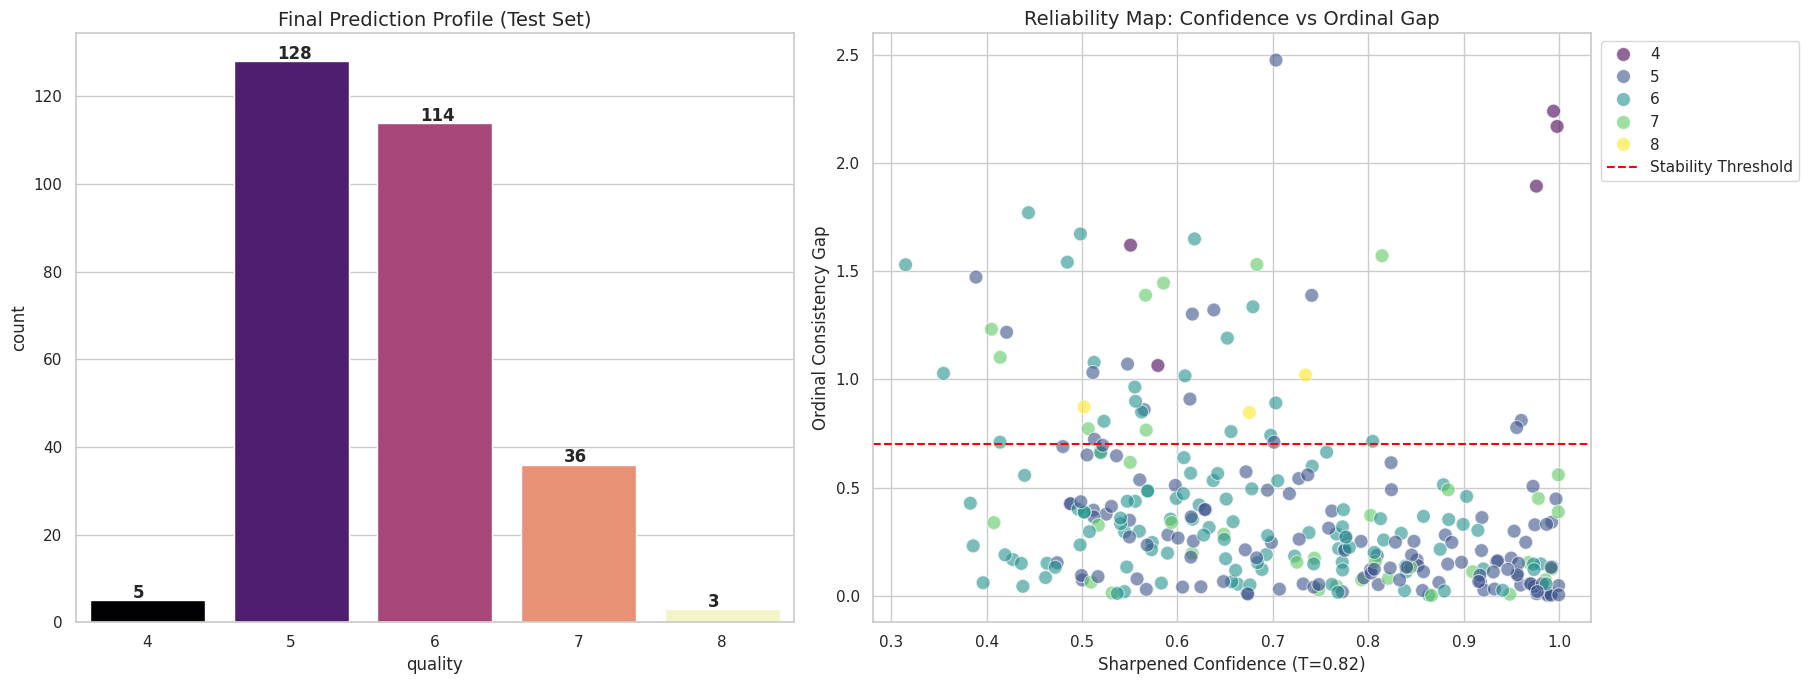


FILE 'submission_final_026.csv' SIAP UNTUK SUBMIT


In [44]:
# 9.6 Visualisasi Diagnostik Akhir
plt.figure(figsize=(18, 7))

# Plot distribusi prediksi final
plt.subplot(1, 2, 1)
ax = sns.countplot(x='quality', data=submission_df, palette='magma', hue='quality', legend=False)
plt.title('Final Prediction Profile (Test Set)', fontsize=14)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+0.3, p.get_height()+0.5), fontweight='bold')

# Peta Reliabilitas: Confidence vs Ordinal Gap
plt.subplot(1, 2, 2)
sns.scatterplot(x='confidence', y='ordinal_gap', hue='quality', data=submission_df, palette='viridis', s=100, alpha=0.6)
plt.axhline(y=0.70, color='red', linestyle='--', label='Stability Threshold')
plt.title('Reliability Map: Confidence vs Ordinal Gap', fontsize=14)
plt.xlabel('Sharpened Confidence (T=0.82)')
plt.ylabel('Ordinal Consistency Gap')
plt.legend(bbox_to_anchor=(1.3, 1))
plt.tight_layout()
plt.show()

# 9.7 Export untuk Submit
file_output = 'submission_final_026.csv'
submission_df[['Id', 'quality']].to_csv(file_output, index=False)
print(f"\nFILE '{file_output}' SIAP UNTUK SUBMIT")